# Fase 2 — Adquisición y EDA (Semana 3-4)

Referencia: `DOCUMENTOS ELABORADOS DE LA TESIS/Protocolo de Investigacion v2.1.md` (secciones 5 y 11, pasos P01-P03; matriz de trazabilidad §12, T01-T03). La sección 8 (añadida para el piloto de Semana 4) referencia además P04-P06.

**Alcance de este notebook:**
1. Descargar el dataset UCI id=697 y verificar su integridad contra la ficha técnica del protocolo.
2. Ejecutar el EDA sobre las 3 clases originales (Dropout / Enrolled / Graduate) — sin excluir, filtrar, normalizar ni particionar todavía.
3. (Sección 8, piloto Semana 4) Ejecutar una versión reducida y **no oficial** de P04-P06 sobre una muestra, para producir evidencia real del piloto sin consumir la partición oficial de Fase 3.

**Fuera de alcance de las secciones 1–7 (Fase 2 formal):** exclusión de "Enrolled", binarización, partición train/val/test, normalización, SMOTE sobre el dataset completo — eso es Fase 2 tardía (semana 4, depuración) y Fase 3 (semanas 5-6, partición y pipeline oficiales, que se ejecutan una sola vez y se congelan). La sección 8 es una excepción explícita y acotada: corre sobre una muestra reducida, con salidas marcadas `_piloto` y guardadas en `Pilotaje/<entorno>/evidencias/`, no en `data/processed/`, precisamente para no pisar ni adelantar esa ejecución oficial.


## 0. Entorno

Ejecutar en local (CPU, sin GPU necesaria — ver §10 del protocolo). Dependencias mínimas
para las secciones 1-7 (Fase 2 formal): `ucimlrepo`, `pandas`, `numpy`, `matplotlib`, `seaborn`.

Para la sección 8 (piloto Semana 4) se suman: `scikit-learn`, `imbalanced-learn`, `psutil`
— todas ya declaradas en `requirements.txt` del proyecto, instaladas en el `.venv` dedicado
(ver `Pilotaje/<entorno>/entorno_ejecucion.md` para la versión exacta usada en cada máquina).


In [1]:
# Ejecutar una sola vez si falta alguna dependencia
# %pip install ucimlrepo pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
import platform
from pathlib import Path

# Detecta el entorno (laptop Linux / escritorio Windows) para guardar figuras y
# evidencias en la carpeta de Pilotaje correspondiente, sin tocar el notebook.
_entorno_detectado = {
    "Linux": "laptop_arch_linux",
    "Windows": "escritorio_windows10",
}.get(platform.system(), "entorno_no_reconocido")

RUTA_EVIDENCIAS_PILOTO = Path(f"../../Pilotaje/{_entorno_detectado}/evidencias")
RUTA_FIGURAS_PILOTO = RUTA_EVIDENCIAS_PILOTO / "figuras"
RUTA_FIGURAS_PILOTO.mkdir(parents=True, exist_ok=True)

print(f"Entorno detectado: {_entorno_detectado}")
print(f"Figuras: {RUTA_FIGURAS_PILOTO}")


Entorno detectado: escritorio_windows10
Figuras: ..\..\Pilotaje\escritorio_windows10\evidencias\figuras


## 1. Adquisición del dataset (UCI id=697)

Fuente oficial: UCI Machine Learning Repository, DOI 10.24432/C5MC89 (Realinho et al., 2022).
Kaggle es solo espejo de descarga — no se cita como fuente.

In [4]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
print(dataset.metadata.name)
print(dataset.metadata.doi)
df.head()

Predict Students' Dropout and Academic Success
None


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 1.1 Verificación de integridad

Indicador de cierre (cronograma, semana 3): **0 discrepancias entre metadatos UCI y archivo local.**

Contra la ficha técnica del protocolo:
- Registros esperados: **4,424**
- Variables predictoras esperadas: **35**
- Clases esperadas: **Dropout, Enrolled, Graduate**

In [5]:
n_registros = df.shape[0]
n_variables = X.shape[1]
clases = sorted(y.iloc[:, 0].unique().tolist())

print(f"Registros: {n_registros} (esperado: 4424) -> {'OK' if n_registros == 4424 else 'DISCREPANCIA'}")
print(f"Variables predictoras: {n_variables} (esperado: 35) -> {'OK' if n_variables == 35 else 'DISCREPANCIA'}")
print(f"Clases encontradas: {clases}")

Registros: 4424 (esperado: 4424) -> OK
Variables predictoras: 36 (esperado: 35) -> DISCREPANCIA
Clases encontradas: ['Dropout', 'Enrolled', 'Graduate']


In [6]:
# Guardar copia local cruda, sin modificar, para trazabilidad (data/raw queda fuera de git, ver .gitignore)
ruta_salida = "../../data/raw/dataset_crudo_uci697.csv"
df.to_csv(ruta_salida, index=False)
print(f"Guardado: {ruta_salida}")

Guardado: ../../data/raw/dataset_crudo_uci697.csv


## 1.2 Registro del dataset (Protocolo v2.1, §11 P01 — evidencia T01)

El dataset UCI no trae un identificador propio de estudiante, así que se usa el índice de fila como `student_id` — se documenta esta decisión explícitamente porque reemplaza al `student_id` real que tendría un dataset institucional.

`class_binaria` es únicamente el **mapeo de referencia** (Dropout=1, Graduate=0, Enrolled=NaN) registrado desde ya para trazabilidad; no implica excluir ni transformar el dataset de trabajo todavía — eso sigue correspondiendo a la depuración de la semana 4 (fuera de alcance de este notebook, ver celda 1).

`split` queda como `"pendiente"` porque la partición se decide recién en Fase 3 (semana 5).

In [7]:
mapa_binario = {"Dropout": 1, "Graduate": 0, "Enrolled": np.nan}

df_metadata = pd.DataFrame({
    "student_id": df.index,
    "class_original": df[y.columns[0]].values,
})
df_metadata["class_binaria"] = df_metadata["class_original"].map(mapa_binario)
df_metadata["source"] = "UCI id=697 (DOI 10.24432/C5MC89)"
df_metadata["split"] = "pendiente (se asigna en Fase 3, semana 5)"

ruta_metadata = "../../data/processed/dataset_metadata.csv"
df_metadata.to_csv(ruta_metadata, index=False)
print(f"Guardado: {ruta_metadata} ({len(df_metadata)} filas)")
df_metadata.head()

Guardado: ../../data/processed/dataset_metadata.csv (4424 filas)


,student_id,class_original,class_binaria,source,split
0,0,Dropout,1.0,UCI id=697 (DOI 10.24432/C5MC89),"pendiente (se asigna en Fase 3, semana 5)"
1,1,Graduate,0.0,UCI id=697 (DOI 10.24432/C5MC89),"pendiente (se asigna en Fase 3, semana 5)"
2,2,Dropout,1.0,UCI id=697 (DOI 10.24432/C5MC89),"pendiente (se asigna en Fase 3, semana 5)"
3,3,Graduate,0.0,UCI id=697 (DOI 10.24432/C5MC89),"pendiente (se asigna en Fase 3, semana 5)"
4,4,Graduate,0.0,UCI id=697 (DOI 10.24432/C5MC89),"pendiente (se asigna en Fase 3, semana 5)"


## 2. EDA — Distribución de clases

Sobre las 3 clases originales, **antes** de excluir "Enrolled". Debe aproximarse a lo ya documentado en el protocolo: Dropout 32.1%, Graduate 49.9%, Enrolled 17.9%.

In [8]:
target_col = y.columns[0]

conteo = df[target_col].value_counts()
porcentaje = df[target_col].value_counts(normalize=True) * 100

resumen_clases = pd.DataFrame({"frecuencia": conteo, "porcentaje": porcentaje.round(2)})
resumen_clases

,frecuencia,porcentaje
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


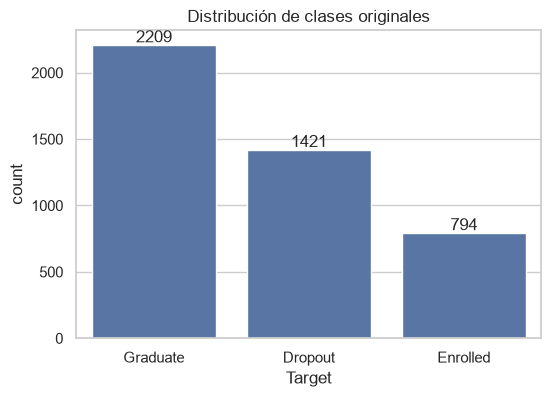

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=target_col, order=conteo.index, ax=ax)
ax.set_title("Distribución de clases originales")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 20, str(v), ha="center")
plt.savefig(RUTA_FIGURAS_PILOTO / "distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.1 Auditoría — duplicados y unicidad de `student_id` (Protocolo v2.1, §11 P02-P03 — evidencia T01/T03)

El modelo de protocolo del curso usa `group_id` para evitar que un mismo origen (lote, grano, sesión de adquisición) quede repartido entre particiones distintas. Este dataset no tiene esa estructura de grupos: cada fila es un estudiante independiente, sin relación conocida con otras filas. El control equivalente de fuga de información aquí es más simple — verificar que no haya filas completamente duplicadas y que `student_id` sea único antes de particionar en Fase 3.

In [10]:
n_duplicados_totales = df.duplicated().sum()
n_ids_unicos = df_metadata["student_id"].nunique()

print(f"Filas totalmente duplicadas: {n_duplicados_totales}")
print(f"student_id únicos: {n_ids_unicos} / {len(df_metadata)} -> {'OK' if n_ids_unicos == len(df_metadata) else 'DISCREPANCIA'}")

Filas totalmente duplicadas: 0
student_id únicos: 4424 / 4424 -> OK


## 3. EDA — Valores faltantes

In [11]:
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

if faltantes.empty:
    print("Sin valores faltantes detectados.")
else:
    display(faltantes)

Sin valores faltantes detectados.


## 4. EDA — Outliers (variables numéricas)

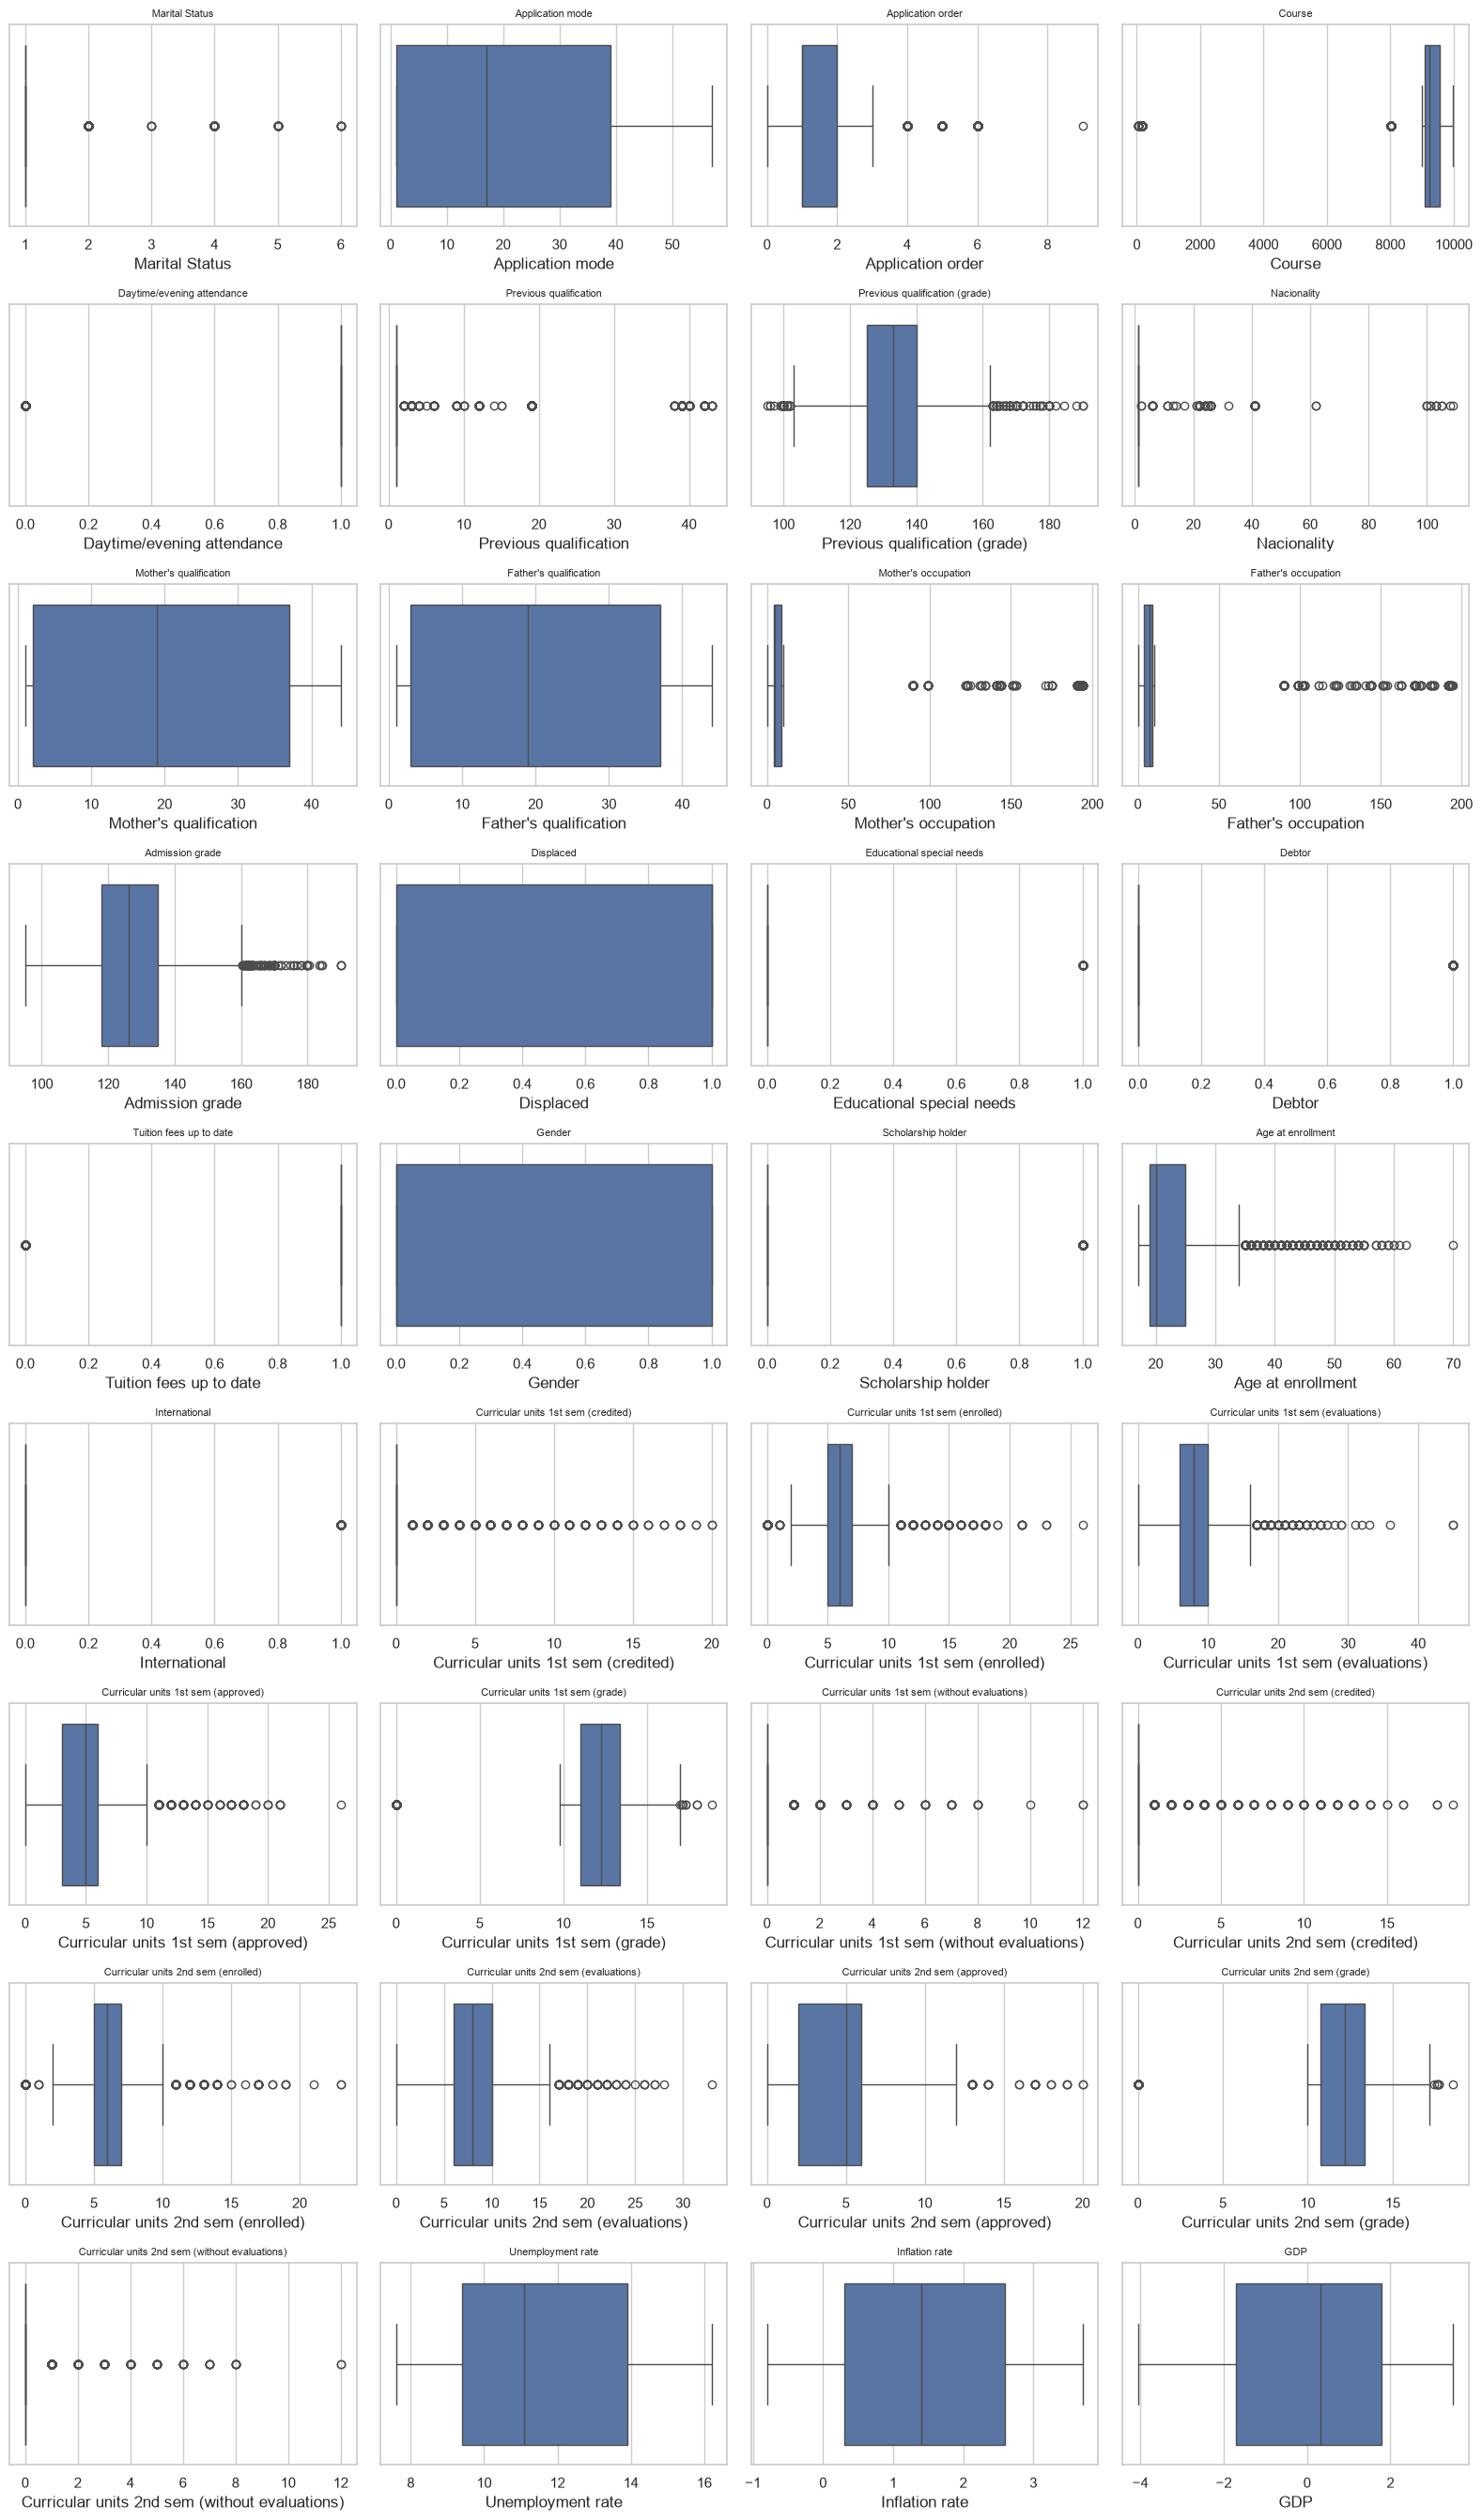

In [12]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

n_cols_plot = 4
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(4 * n_cols_plot, 3 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(RUTA_FIGURAS_PILOTO / "outliers_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Conteo de outliers por IQR, solo para documentar -- no se elimina nada en esta fase
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < limite_inf) | (serie > limite_sup)).sum()

outliers_resumen = pd.Series({col: contar_outliers_iqr(df[col]) for col in num_cols}).sort_values(ascending=False)
outliers_resumen.to_frame("n_outliers_iqr")

,n_outliers_iqr
Scholarship holder,1099
Curricular units 2nd sem (grade),877
Curricular units 1st sem (grade),726
Previous qualification,707
Curricular units 1st sem (credited),577
Application order,541
Curricular units 2nd sem (credited),530
Tuition fees up to date,528
Marital Status,505
Debtor,503


## 5. EDA — Correlaciones entre variables predictoras

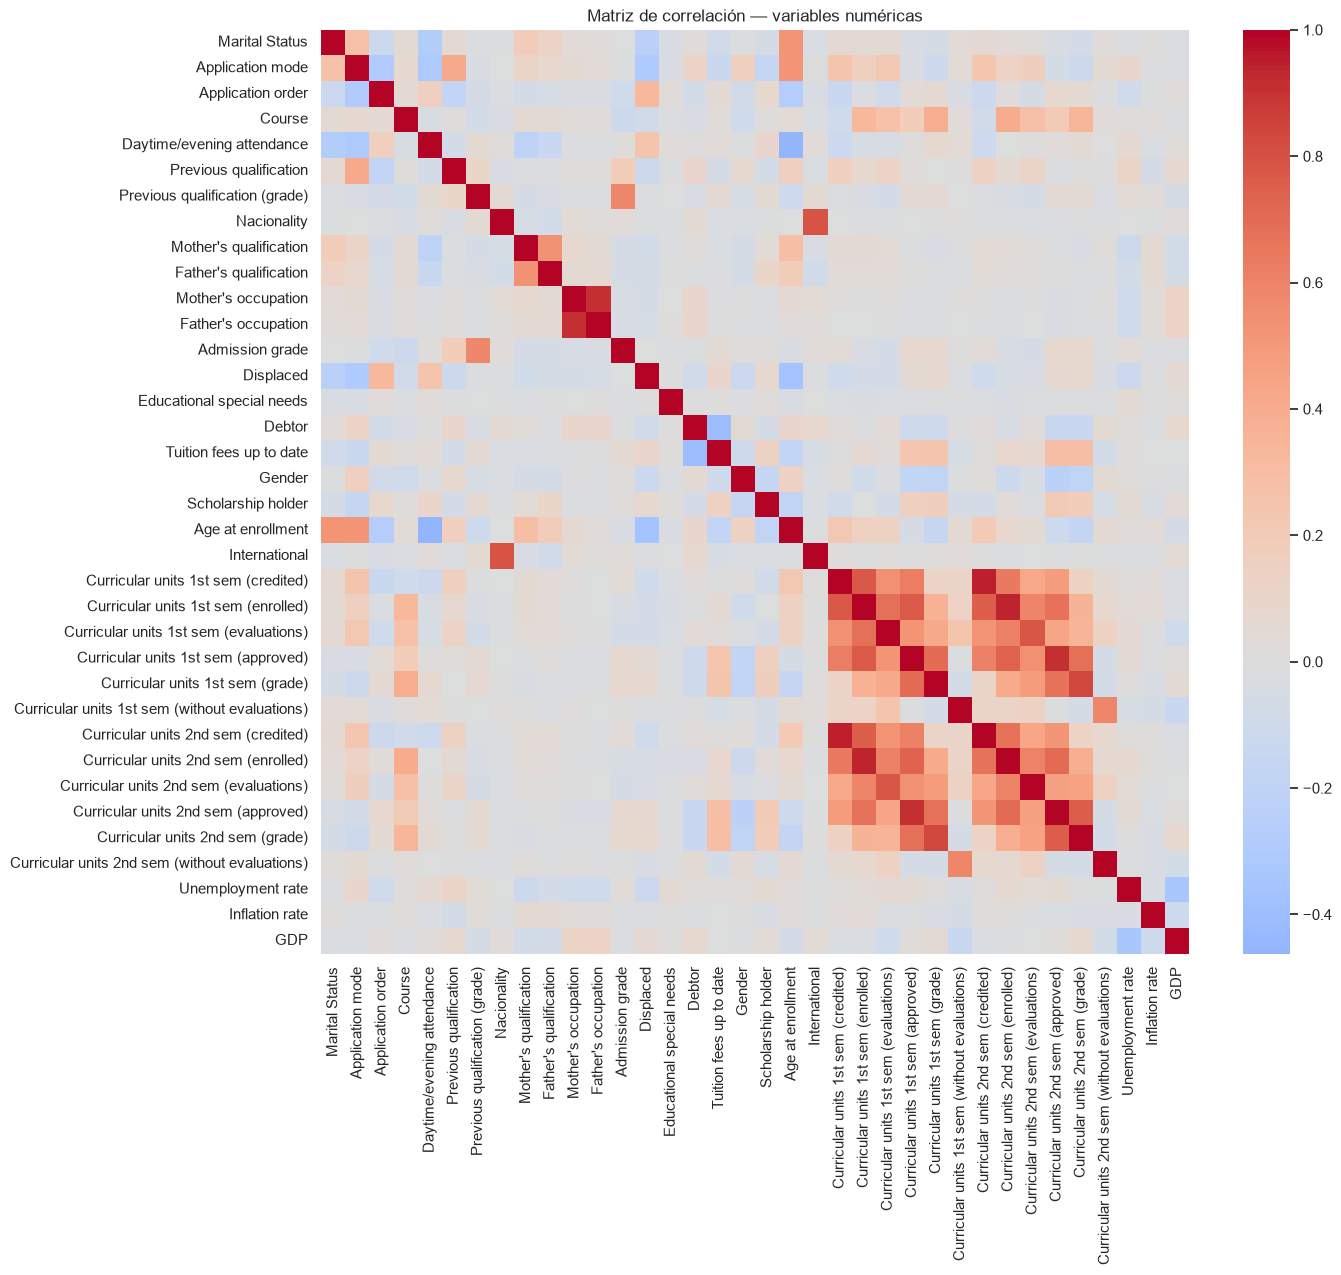

In [14]:
corr = X[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación — variables numéricas")
plt.savefig(RUTA_FIGURAS_PILOTO / "matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Pares con correlación alta (|r| > 0.8), candidatos a redundancia -- documentar, no eliminar aún
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
corr_pairs.drop_duplicates().head(15)

Curricular units 2nd sem (credited)     Curricular units 1st sem (credited)       0.944811
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.942627
Father's occupation                     Mother's occupation                       0.910472
Curricular units 2nd sem (approved)     Curricular units 1st sem (approved)       0.904002
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837170
Nacionality                             International                             0.790935
Curricular units 2nd sem (evaluations)  Curricular units 1st sem (evaluations)    0.778863
Curricular units 1st sem (enrolled)     Curricular units 1st sem (credited)       0.774344
                                        Curricular units 1st sem (approved)       0.769083
Curricular units 2nd sem (grade)        Curricular units 2nd sem (approved)       0.760804
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (credited)       0.753747

## 6. Auditoría consolidada y resumen (Protocolo v2.1, §11 P02 — evidencia T01/T02)

Consolida los resultados de integridad, duplicados, faltantes, distribución de clases y correlaciones en `dataset_audit.csv`, la evidencia que pide el protocolo v2.1 para cerrar T01/T02 de la matriz de trazabilidad.

In [16]:
resumen_auditoria = {
    "n_registros_totales": n_registros,
    "n_variables_predictoras": n_variables,
    "clases_encontradas": ", ".join(clases),
    "discrepancia_registros": n_registros != 4424,
    "discrepancia_variables": n_variables != 35,
    "filas_duplicadas": int(n_duplicados_totales),
    "student_id_unicos_ok": bool(n_ids_unicos == len(df_metadata)),
    "variables_con_faltantes": int((faltantes > 0).sum()) if not faltantes.empty else 0,
    "total_valores_faltantes": int(faltantes.sum()) if not faltantes.empty else 0,
    "dropout_pct": round(float(porcentaje.get("Dropout", 0)), 2),
    "graduate_pct": round(float(porcentaje.get("Graduate", 0)), 2),
    "enrolled_pct": round(float(porcentaje.get("Enrolled", 0)), 2),
    "distribucion_coincide_con_protocolo_v2": all([
        abs(float(porcentaje.get("Dropout", 0)) - 32.1) < 1,
        abs(float(porcentaje.get("Graduate", 0)) - 49.9) < 1,
        abs(float(porcentaje.get("Enrolled", 0)) - 17.9) < 1,
    ]),
    "variables_con_mas_de_5_outliers_iqr": int((outliers_resumen > 5).sum()),
}

df_audit_general = pd.DataFrame([resumen_auditoria])
ruta_audit = "../../data/processed/dataset_audit.csv"
df_audit_general.to_csv(ruta_audit, index=False)
print(f"Guardado: {ruta_audit}")
df_audit_general.T

Guardado: ../../data/processed/dataset_audit.csv


,0
n_registros_totales,4424
n_variables_predictoras,36
clases_encontradas,"Dropout, Enrolled, Graduate"
discrepancia_registros,False
discrepancia_variables,True
filas_duplicadas,0
student_id_unicos_ok,True
variables_con_faltantes,0
total_valores_faltantes,0
dropout_pct,32.12


## 7. Resumen para el Informe EDA (entregable de la semana 3-4)

Completar con lo observado, apoyándose en `dataset_audit.csv` generado arriba, antes de pasar a la depuración (semana 4):

- Distribución de clases: `[ completar ]`
- ¿Coincide con lo documentado en el protocolo (32.1% / 49.9% / 17.9%)? `[ Sí / No, diferencia: ___ ]`
- Valores faltantes relevantes: `[ completar ]`
- Variables con más outliers: `[ completar ]`
- Pares de variables altamente correlacionadas (candidatas a redundancia): `[ completar ]`
- Observaciones que afectan el preprocesamiento de la Fase 3: `[ completar ]`

## 8. Piloto Semana 4 — P04–P05 sobre una muestra reducida (NO es la partición oficial de Fase 3)

Esta sección corresponde al Laboratorio de la Semana 4 ("Ejecución del Piloto y
Retroalimentación"), no a la Fase 2 original de este notebook (secciones 1-7, ya
cerradas arriba).

**Decisión metodológica explícita:** la partición oficial 70/15/15 sobre el dataset
completo (Protocolo v2.1 §11 P04) corresponde a Fase 3 (semana 5) y debe ejecutarse una
sola vez y congelarse — es la regla del test aislado. Ejecutarla aquí, dentro del
piloto, la consumiría antes de tiempo. Por eso esta sección trabaja sobre una
**muestra estratificada reducida** (no el dataset completo) y guarda sus salidas con
sufijo `_piloto` en `Pilotaje/<entorno>/evidencias/` — nunca en `data/processed/` — de
forma que quede inequívoco que esto no reemplaza la ejecución oficial de Fase 3.

Pasos del Protocolo v2.1 §11 ejercitados aquí (sobre la muestra, no el dataset
completo): P04 (partición) → P05 (pipeline: escalado, SMOTE). La muestra y el split
quedan guardados para que los notebooks de entrenamiento los reutilicen sin recalcular
nada — **el entrenamiento de cada modelo vive en su propio notebook, modular**, para
que probar un segundo algoritmo no implique reescribir ni volver a ejecutar la
adquisición/EDA:

- `02_Piloto_Baseline_RegresionLogistica.ipynb` — P06, baseline (Protocolo v2.1 §6).
- `03_Piloto_RandomForest.ipynb` — un segundo modelo (Random Forest, hiperparámetros
  por defecto, **sin tuning**) ejecutado solo para confirmar que el pipeline es
  agnóstico al algoritmo. No reemplaza ni adelanta el entrenamiento con tuning de
  Optuna de Fase 4 (semana 8, Protocolo v2.1 §11 P07) — es una corrida piloto extra,
  no oficial, igual que todo lo demás en esta sección.


In [17]:
import csv
import json
import platform
import shutil
import time
from pathlib import Path

import psutil

# El notebook se ejecuta sin cambios en ambos entornos: detecta en cuál está
# corriendo y escribe la bitácora/evidencias en la carpeta de Pilotaje que corresponde.
_entorno_detectado = {
    "Linux": "laptop_arch_linux",
    "Windows": "escritorio_windows10",
}.get(platform.system(), "entorno_no_reconocido")

RUTA_BITACORA = Path(f"../../Pilotaje/{_entorno_detectado}/bitacora_ejecucion.csv")
RUTA_EVIDENCIAS_PILOTO = Path(f"../../Pilotaje/{_entorno_detectado}/evidencias")
RUTA_EVIDENCIAS_PILOTO.mkdir(parents=True, exist_ok=True)

_proceso = psutil.Process()


def _siguiente_contador():
    """Continúa la numeración P-01, P-02... donde la haya dejado el último notebook
    que escribió en esta bitácora (01, 02 o 03), para que los pasos de los distintos
    notebooks del piloto no se pisen con el mismo id."""
    if RUTA_BITACORA.exists() and RUTA_BITACORA.stat().st_size > 0:
        with open(RUTA_BITACORA, newline="", encoding="utf-8") as f:
            ids = [fila["id"] for fila in csv.DictReader(f)]
        numeros = [int(i.split("-")[1]) for i in ids if i.startswith("P-")]
        return max(numeros) if numeros else 0
    return 0


_contador_pasos = [_siguiente_contador()]


class registrar_paso:
    """Context manager: mide tiempo y memoria (RSS) de un bloque y registra la fila
    en la bitácora del piloto del entorno detectado. Usa psutil (no el módulo
    'resource', que no existe en Windows) para que el mismo código funcione en ambas
    máquinas sin modificarlo."""

    def __init__(self, accion, entrada, esperado, evidencia=""):
        self.accion, self.entrada, self.esperado, self.evidencia = accion, entrada, esperado, evidencia

    def __enter__(self):
        self.t0 = time.perf_counter()
        self.mem_inicio_mb = _proceso.memory_info().rss / 1024**2
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        _contador_pasos[0] += 1
        duracion = round(time.perf_counter() - self.t0, 3)
        mem_fin_mb = _proceso.memory_info().rss / 1024**2
        delta_mem_mb = round(mem_fin_mb - self.mem_inicio_mb, 1)
        observado = "OK" if exc_type is None else f"ERROR: {exc_val}"
        incidencia = "" if exc_type is None else str(exc_val)
        fila = {
            "id": f"P-{_contador_pasos[0]:02d}",
            "accion": self.accion,
            "entrada": self.entrada,
            "esperado": self.esperado,
            "observado": f"{observado} | tiempo={duracion}s | rss_actual={round(mem_fin_mb, 1)}MB | delta_mem={delta_mem_mb}MB",
            "incidencia": incidencia,
            "evidencia": self.evidencia,
        }
        existe_con_contenido = RUTA_BITACORA.exists() and RUTA_BITACORA.stat().st_size > 0
        with open(RUTA_BITACORA, "a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=list(fila.keys()))
            if not existe_con_contenido:
                w.writeheader()
            w.writerow(fila)
        print(f"[{fila['id']}] {self.accion} -> {fila['observado']}")
        return False  # no silenciar excepciones


print(f"Entorno detectado: {_entorno_detectado}")
print(f"Bitácora: {RUTA_BITACORA}")
print(f"Evidencias del piloto: {RUTA_EVIDENCIAS_PILOTO}")


Entorno detectado: escritorio_windows10
Bitácora: ..\..\Pilotaje\escritorio_windows10\bitacora_ejecucion.csv
Evidencias del piloto: ..\..\Pilotaje\escritorio_windows10\evidencias


### 8.1 Muestra piloto: excluir "Enrolled", binarizar y tomar subconjunto estratificado (prep. para P04)

In [18]:
from sklearn.model_selection import train_test_split

TAMANO_MUESTRA_PILOTO = 1200  # subconjunto, no el dataset completo (ver nota metodológica arriba)
SEED = 42

with registrar_paso(
    accion='Excluir "Enrolled", binarizar y tomar muestra piloto estratificada',
    entrada=f"df completo ({len(df)} filas, 3 clases)",
    esperado=f"~{TAMANO_MUESTRA_PILOTO} filas, 2 clases (Dropout/Graduate), proporción similar al dataset completo",
    evidencia="dataset_muestra_piloto.csv",
):
    df_binario = df[df[target_col] != "Enrolled"].copy()
    df_binario["class_binaria"] = df_binario[target_col].map({"Dropout": 1, "Graduate": 0})

    df_muestra_piloto, _ = train_test_split(
        df_binario,
        train_size=TAMANO_MUESTRA_PILOTO,
        stratify=df_binario["class_binaria"],
        random_state=SEED,
    )

    df_muestra_piloto.to_csv(RUTA_EVIDENCIAS_PILOTO / "dataset_muestra_piloto.csv", index=False)

print(df_muestra_piloto["class_binaria"].value_counts(normalize=True).round(3))


[P-01] Excluir "Enrolled", binarizar y tomar muestra piloto estratificada -> OK | tiempo=0.044s | rss_actual=247.9MB | delta_mem=5.4MB
class_binaria
0    0.608
1    0.392
Name: proportion, dtype: float64


### 8.2 Partición piloto 70/15/15 estratificada (P04, sobre la muestra — no la oficial)

In [19]:
with registrar_paso(
    accion="Particionar la muestra piloto 70/15/15 estratificada",
    entrada=f"muestra piloto ({len(df_muestra_piloto)} filas)",
    esperado="train~70%, val~15%, test~15%, proporción de clase preservada en cada split",
    evidencia="dataset_split_piloto.csv",
):
    df_train_piloto, df_temp_piloto = train_test_split(
        df_muestra_piloto, test_size=0.30, stratify=df_muestra_piloto["class_binaria"], random_state=SEED
    )
    df_val_piloto, df_test_piloto = train_test_split(
        df_temp_piloto, test_size=0.50, stratify=df_temp_piloto["class_binaria"], random_state=SEED
    )

    df_split_piloto = pd.concat([
        df_train_piloto.assign(split="train"),
        df_val_piloto.assign(split="val"),
        df_test_piloto.assign(split="test"),
    ])
    df_split_piloto.to_csv(RUTA_EVIDENCIAS_PILOTO / "dataset_split_piloto.csv", index=False)

print(f"train={len(df_train_piloto)} val={len(df_val_piloto)} test={len(df_test_piloto)}")
print(df_split_piloto.groupby("split")["class_binaria"].mean().round(3))


[P-02] Particionar la muestra piloto 70/15/15 estratificada -> OK | tiempo=0.013s | rss_actual=248.4MB | delta_mem=0.5MB
train=840 val=180 test=180
split
test     0.389
train    0.392
val      0.394
Name: class_binaria, dtype: float64


### 8.3 Pipeline de preprocesamiento (P05): escalado + SMOTE solo en train

In [20]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler

cols_features_piloto = [c for c in df_split_piloto.columns if c not in {target_col, "class_binaria", "split"}]

X_train_piloto = df_train_piloto[cols_features_piloto]
y_train_piloto = df_train_piloto["class_binaria"]
X_val_piloto = df_val_piloto[cols_features_piloto]
y_val_piloto = df_val_piloto["class_binaria"]

with registrar_paso(
    accion="Ajustar pipeline de preprocesamiento (StandardScaler + SMOTE) solo sobre train",
    entrada=f"train piloto ({len(X_train_piloto)} filas, {X_train_piloto.shape[1]} variables)",
    esperado="fit únicamente sobre train; val transformado con el mismo escalador, sin SMOTE",
    evidencia="pipeline_config_piloto.json",
):
    pipeline_piloto = ImbPipeline(steps=[
        ("escalado", StandardScaler()),
        ("smote", SMOTE(random_state=SEED)),
    ])
    X_train_proc, y_train_proc = pipeline_piloto.fit_resample(X_train_piloto, y_train_piloto)

    # Val: mismo escalador ajustado en train, SIN SMOTE (P05: SMOTE solo en folds de entrenamiento)
    X_val_proc = pipeline_piloto.named_steps["escalado"].transform(X_val_piloto)

    pipeline_config_piloto = {
        "pasos": ["StandardScaler", "SMOTE(random_state=42)"],
        "nota": "SMOTE aplicado solo sobre train (P05 del protocolo); val solo transformado, nunca re-ajustado",
        "n_train_antes_smote": int(len(X_train_piloto)),
        "n_train_despues_smote": int(len(X_train_proc)),
        "variables_usadas": cols_features_piloto,
    }
    with open(RUTA_EVIDENCIAS_PILOTO / "pipeline_config_piloto.json", "w", encoding="utf-8") as f:
        json.dump(pipeline_config_piloto, f, indent=2, ensure_ascii=False)

print(f"Train antes de SMOTE: {len(X_train_piloto)} -> después: {len(X_train_proc)}")


[P-03] Ajustar pipeline de preprocesamiento (StandardScaler + SMOTE) solo sobre train -> OK | tiempo=0.056s | rss_actual=267.2MB | delta_mem=3.2MB
Train antes de SMOTE: 840 -> después: 1022


### 8.4 Consolidar evidencias del piloto en un único directorio por entorno

Copia `dataset_metadata.csv` y `dataset_audit.csv` (generados en las secciones 1-6, Fase
2 formal) hacia `Pilotaje/<entorno>/evidencias/`, para que toda la evidencia del piloto
de este entorno quede junta y sea comparable con la del otro entorno.

In [21]:
with registrar_paso(
    accion="Copiar evidencias P01-P03 (metadata, auditoría) al directorio del piloto de este entorno",
    entrada="data/processed/dataset_metadata.csv, data/processed/dataset_audit.csv",
    esperado="ambos archivos presentes en Pilotaje/<entorno>/evidencias/",
    evidencia="dataset_metadata.csv, dataset_audit.csv (copia)",
):
    shutil.copy(ruta_metadata, RUTA_EVIDENCIAS_PILOTO / "dataset_metadata.csv")
    shutil.copy(ruta_audit, RUTA_EVIDENCIAS_PILOTO / "dataset_audit.csv")

print("Evidencias P01-P03 copiadas a", RUTA_EVIDENCIAS_PILOTO)


[P-04] Copiar evidencias P01-P03 (metadata, auditoría) al directorio del piloto de este entorno -> OK | tiempo=0.01s | rss_actual=267.2MB | delta_mem=0.0MB
Evidencias P01-P03 copiadas a ..\..\Pilotaje\escritorio_windows10\evidencias


## 9. Semáforo y síntesis del piloto

Completado tras revisar la bitácora (`Pilotaje/laptop_arch_linux/bitacora_ejecucion.csv`),
`dataset_audit.csv` y el log de incidencias (`Pilotaje/incidencias_log.csv`), siguiendo la
Etapa C/Etapa E del "Laboratorio Semana 4 — Ejecución del Piloto y Retroalimentación".

**Semáforo: 🟡 AMARILLO** — el pipeline corrió limpio (0 errores en 41 celdas, métricas
coherentes), pero quedan 2 incidencias reales sin resolver que tocan la ficha técnica del
protocolo (INC-01 entorno, INC-02 variables): se ejecutó, pero requiere correcciones antes
de la ejecución definitiva. No es rojo porque ninguna incidencia impide continuar — ambas
son de documentación/decisión, no de datos corruptos o pipeline roto.

1. **¿Qué funcionó exactamente como estaba previsto? ¿Qué evidencia lo demuestra?**
   Las 3 verificaciones que el protocolo exigía: integridad del dataset (4,424 registros,
   0 discrepancia), distribución de clases (32.12%/49.93%/17.95% vs. 32.1%/49.9%/17.9%
   esperado) y unicidad de `student_id` (sin duplicados). Evidencia: `dataset_audit.csv`,
   bitácora con los 5 pasos en "OK".

2. **¿Qué parecía claro al escribir el protocolo, pero fue ambiguo al ejecutarlo?**
   El §10 asumía un solo entorno (Windows 10) sin prever que el trabajo real ocurre
   también en Linux. El §5 daba por buena la cifra de "35 variables" del paper original
   sin verificarla contra la copia real descargada. Ninguna de las dos se iba a notar
   sin ejecutar de verdad.

3. **¿Qué decisión tuvo que tomar durante el piloto que NO estaba definida?**
   Correr P04-P06 sobre una muestra estratificada (1200 filas) en vez de la partición
   oficial completa, para no congelar prematuramente la partición de Fase 3 — el
   protocolo no contemplaba el caso "piloto vs. ejecución oficial".

4. **¿La evidencia obtenida realmente permite responder al objetivo relacionado?**
   Parcial. Para OE1 (EDA/variables) sí, da insumos reales. Para OE2 (comparar los 4
   algoritmos) solo parcialmente: el piloto entrenó el baseline (AUC-ROC 0.963, notebook
   02) y, de forma modular en un notebook aparte (03), un segundo modelo —
   Random Forest sin tuning (AUC-ROC 0.954) — sobre la misma partición piloto, para
   confirmar que el pipeline es agnóstico al algoritmo y no quedó acoplado al baseline
   por accidente. Esto no reemplaza la comparación real de Fase 4-6 (con tuning de
   Optuna, los 4 modelos, partición oficial y ruta estadística completa), pero sí da más
   confianza de que el pipeline escalará a los 4 modelos sin sorpresas estructurales.

5. **¿Los datos/muestra mostraron problemas de calidad, disponibilidad, etiquetado,
   representatividad o independencia?**
   Calidad: ninguno (0 duplicados, 0 faltantes). Sí se detectaron 28 variables con más de
   5 outliers IQR (`dataset_audit.csv`) — no es un problema en sí, pero a vigilar en Fase
   3. La discrepancia de variables (INC-02) es un problema de documentación, no de
   calidad del dato en sí.

6. **¿La métrica o criterio pudo aplicarse como estaba previsto? ¿Es suficiente?**
   Sí, AUC-ROC/F1/precisión/recall/exactitud se calcularon sin problema sobre la muestra
   piloto. Suficiente para el piloto (confirma mecánica); para la evaluación definitiva
   falta aplicarla sobre los 4 modelos y sobre el test congelado (Fase 5).

7. **¿Detectó riesgo de sesgo, fuga de datos, pérdida de información o medición
   incorrecta?**
   No se detectó fuga: SMOTE solo se aplicó en train, val solo transformado (verificable
   en `pipeline_config_piloto.json`). La muestra piloto (1200/3630) no es representativa
   definitiva, pero es aceptable porque es un piloto, no el resultado final.

8. **¿Qué parámetro, condición, instrumento o paso debe definirse mejor?**
   Las dos incidencias pendientes: si el §5 del protocolo pasa de 35 a 36 variables
   predictoras (INC-02), y si el §10 se actualiza para reflejar ambos entornos de
   cómputo (INC-01).

9. **¿Qué NO debe cambiar aunque el resultado preliminar no sea el esperado? ¿Por qué?**
   La partición estratificada 70/15/15 con seed=42 ya congelada, y el recall de la clase
   "Dropout" como criterio de desempate — están definidos por costo de negocio (un falso
   negativo es más caro que un falso positivo), no por conveniencia estadística. En este
   piloto el resultado sí fue el esperado, así que no hubo tentación real de tocar esto.

10. **Si otra persona recibiera el protocolo, ¿qué todavía necesitaría preguntar para
    reproducirlo?**
    Nada técnico mayor — entorno, seed y código ya están capturados
    (`requirements_lock.txt`, `entorno_ejecucion.md`, seed=42 fijo). Solo preguntaría qué
    se decidió con INC-01/INC-02, porque el protocolo todavía no las resuelve.

11. **¿Qué error descubierto podría haber comprometido toda la tesis si se detectaba
    después?**
    INC-02. Si se llega a Fase 6 (resultados finales) y recién ahí un jurado nota que la
    ficha técnica documentada no coincide con los datos reales usados, es una observación
    grave sobre rigor metodológico. Detectarlo en el piloto (Semana 4) en vez de en la
    entrega final es exactamente el valor del piloto.

12. **Después del piloto, ¿el cronograma sigue siendo viable? ¿Qué debe ajustarse?**
    Sí, sigue viable sin mover fechas. Se agrega una micro-tarea antes de Fase 3 (semana
    5): resolver INC-01/INC-02 y, si corresponde, emitir Protocolo v2.2.
